# 60 — LSEG/Gemma hybrid long-leg exposure control

**Question.** Notebook 59 found that the unchanged Notebook 36 long leg supplied almost all historical gross contribution. Does that selected long leg beat matched broad-market and same-sector exposure controls?

The design was frozen in `frozen_specs/lseg_gemma_hybrid_long_leg_exposure_control_v1.json` before either comparison was computed. Signal dates, Gemma event counts, FinBERT-selected names, positive weights, original sector-33 universe, and the open-to-open return interval remain unchanged. This is a post-result mechanism diagnostic on an opened window, not another strategy search or an alpha-validation test. Licensed headline text is neither loaded nor emitted.

In [1]:
from __future__ import annotations

import hashlib
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from statsmodels.stats.multitest import multipletests

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'final_experiments':
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import paired_block_bootstrap_difference  # noqa: E402
from final_experiments.lib.sector_portfolios import SECTOR_MEMBERS  # noqa: E402
from final_experiments.lib.sparse_spread import build_exact_extrema_targets  # noqa: E402

SPEC_PATH = REPO_ROOT / 'final_experiments/frozen_specs/lseg_gemma_hybrid_long_leg_exposure_control_v1.json'
AGGREGATE_DIR = REPO_ROOT / 'final_experiments/outputs/13_lseg_44_gemma_robustness'
GEMMA_PATH = AGGREGATE_DIR / 'gemma4_26b_firm_open_aggregators.parquet'
FINBERT_PATH = AGGREGATE_DIR / 'finbert_firm_open_aggregators.parquet'
PRICE_PATH = REPO_ROOT / 'Data/derived/prices/lseg_us_sector_33_8m.csv'
PRICE_MANIFEST_PATH = REPO_ROOT / 'Data/derived/prices/lseg_us_sector_33_8m.manifest.json'
NOTEBOOK59_DAILY_PATH = REPO_ROOT / 'final_experiments/outputs/59_lseg_gemma_hybrid_session_decomposition/daily_component_audit.parquet'
OUTPUT_DIR = REPO_ROOT / 'final_experiments/outputs/60_lseg_gemma_hybrid_long_leg_exposure_control'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

spec = json.loads(SPEC_PATH.read_text())
assert spec['status'] == 'frozen_before_control_outcomes'
SEED = int(spec['inference']['seed'])
BLOCK_LENGTH = int(spec['inference']['block_length_sessions'])
REPLICATIONS = int(spec['inference']['replications'])
BH_Q = float(spec['inference']['bh_q'])
SINGLE_NAME_CAP = 0.25
IDENTITY_TOLERANCE = 1e-12
apply_house_style()
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda value: f'{value:,.6f}')

## Reconstruct the unchanged selected long leg and matched controls

For each session, the broad-market control spreads the selected leg's total positive target weight equally across all 33 names. The same-sector control first preserves every sector's selected positive exposure and then spreads that exposure equally across the sector's three original constituents. Both controls therefore use the same dates, start-open-normalized gross exposure, and open-to-open interval; the sector control additionally holds sector allocation exactly fixed.

In [2]:
sector_members = {sector: tuple(members[:3]) for sector, members in SECTOR_MEMBERS.items()}
original_symbols = tuple(symbol for members in sector_members.values() for symbol in members)
symbols = tuple(sorted(original_symbols))
sector_by_symbol = {symbol: sector for sector, members in sector_members.items() for symbol in members}
if len(symbols) != 33 or len(sector_members) != 11 or any(len(members) != 3 for members in sector_members.values()):
    raise ValueError('expected immutable original 33 in eleven three-company sectors')

gemma = pd.read_parquet(GEMMA_PATH)
finbert = pd.read_parquet(FINBERT_PATH)
for frame in (gemma, finbert):
    frame['session_date'] = pd.to_datetime(frame['session_date']).dt.normalize()
gemma = gemma.loc[gemma['symbol'].isin(symbols)].copy()
finbert = finbert.loc[finbert['symbol'].isin(symbols)].copy()
if not gemma[['session_date', 'symbol']].equals(finbert[['session_date', 'symbol']]):
    raise ValueError('paired scorer panels are not row-aligned')
if gemma.duplicated(['session_date', 'symbol']).any() or finbert['strongest_event'].isna().any():
    raise ValueError('candidate scorer input is invalid')
sessions = pd.DatetimeIndex(sorted(gemma['session_date'].unique()))
if len(sessions) != 167 or set(gemma['symbol'].unique()) != set(symbols):
    raise ValueError('expected 167 sessions and immutable original 33')

prices = pd.read_csv(PRICE_PATH, parse_dates=['session_date'])
prices['session_date'] = pd.to_datetime(prices['session_date']).dt.normalize()
prices = prices.loc[prices['symbol'].isin(symbols)].copy()
price_manifest = json.loads(PRICE_MANIFEST_PATH.read_text())
assert price_manifest['return_convention'] == 'split-adjusted price returns; dividends not back-adjusted'
assert hashlib.sha256(PRICE_PATH.read_bytes()).hexdigest() == price_manifest['file']['sha256']
open_wide = prices.pivot(index='session_date', columns='symbol', values='open').sort_index().dropna()
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise ValueError('signal sessions are not consecutive complete-price sessions')
if locations[-1] + 1 >= len(open_wide):
    raise ValueError('last signal session has no following open')
next_sessions = open_wide.index[locations + 1]
current_open = open_wide.loc[sessions, list(symbols)].to_numpy(dtype=float)
next_open = open_wide.loc[next_sessions, list(symbols)].to_numpy(dtype=float)
return_matrix = next_open / current_open - 1.0

def rank_map(frame: pd.DataFrame) -> dict[pd.Timestamp, tuple[str, ...]]:
    result = {
        pd.Timestamp(session): tuple(
            day.sort_values(['strongest_event', 'symbol'], ascending=[False, True], kind='mergesort')['symbol']
        )
        for session, day in frame.groupby('session_date', sort=True)
    }
    if len(result) != len(sessions) or any(set(row) != set(symbols) for row in result.values()):
        raise ValueError('rank map is incomplete')
    return result

_, target_audit = build_exact_extrema_targets(gemma, single_name_cap=SINGLE_NAME_CAP)
if not np.array_equal(pd.to_datetime(target_audit['session_date']).to_numpy(), sessions.to_numpy()):
    raise ValueError('target audit is not aligned to the session spine')
ranks = rank_map(finbert)
symbol_index = {symbol: index for index, symbol in enumerate(symbols)}
selected_weights = np.zeros((len(sessions), len(symbols)), dtype=float)
for row_index, row in enumerate(target_audit.itertuples(index=False)):
    n_long, n_short, eligible = int(row.positive_names), int(row.negative_names), bool(row.eligible)
    if not eligible:
        continue
    ranked = ranks[pd.Timestamp(row.session_date)]
    long_symbols = ranked[:n_long]
    short_symbols = ranked[-n_short:]
    if not n_long or not n_short or set(long_symbols) & set(short_symbols):
        raise RuntimeError('invalid hybrid rank selection')
    leg_exposure = min(0.5, SINGLE_NAME_CAP * n_long, SINGLE_NAME_CAP * n_short)
    for symbol in long_symbols:
        selected_weights[row_index, symbol_index[symbol]] = leg_exposure / n_long
if selected_weights.min() < 0 or selected_weights.max() > SINGLE_NAME_CAP + IDENTITY_TOLERANCE:
    raise RuntimeError('selected long weights violate the frozen bounds')

long_exposure = selected_weights.sum(axis=1)
market_weights = np.repeat((long_exposure / len(symbols))[:, None], len(symbols), axis=1)
sector_weights = np.zeros_like(selected_weights)
sector_exposure_errors = []
for sector, members in sector_members.items():
    indices = np.array([symbol_index[symbol] for symbol in members], dtype=int)
    exposure = selected_weights[:, indices].sum(axis=1)
    sector_weights[:, indices] = exposure[:, None] / len(indices)
    sector_exposure_errors.append(np.abs(sector_weights[:, indices].sum(axis=1) - exposure))
gross_exposure_error = float(max(
    np.abs(market_weights.sum(axis=1) - long_exposure).max(),
    np.abs(sector_weights.sum(axis=1) - long_exposure).max(),
))
sector_exposure_error = float(np.concatenate(sector_exposure_errors).max())
if max(gross_exposure_error, sector_exposure_error) > IDENTITY_TOLERANCE:
    raise RuntimeError('control exposure matching failed')

selected_return = np.sum(selected_weights * return_matrix, axis=1)
market_control_return = np.sum(market_weights * return_matrix, axis=1)
sector_control_return = np.sum(sector_weights * return_matrix, axis=1)
n59 = pd.read_parquet(NOTEBOOK59_DAILY_PATH).reset_index(drop=True)
n59['session_date'] = pd.to_datetime(n59['session_date']).dt.normalize()
if not np.array_equal(n59['session_date'].to_numpy(), sessions.to_numpy()):
    raise ValueError('Notebook 59 daily path is not aligned')
selected_identity_error = float(np.max(np.abs(selected_return - n59['long_gross_contribution'].to_numpy(dtype=float))))
if selected_identity_error > IDENTITY_TOLERANCE:
    raise RuntimeError('selected long leg does not reproduce Notebook 59')

daily = pd.DataFrame({
    'session_date': sessions, 'return_end_date': next_sessions,
    'selected_long_gross_contribution': selected_return,
    'equal_weight_market_gross_contribution': market_control_return,
    'same_sector_equal_weight_gross_contribution': sector_control_return,
    'selected_minus_market': selected_return - market_control_return,
    'selected_minus_same_sector': selected_return - sector_control_return,
    'long_gross_exposure': long_exposure,
})
daily['active'] = daily['long_gross_exposure'].gt(0)
identity = pd.DataFrame([{
    'selected_long_vs_notebook59_max_error': selected_identity_error,
    'matched_total_long_exposure_max_error': gross_exposure_error,
    'matched_sector_exposure_max_error': sector_exposure_error,
    'sessions': len(daily), 'active_sessions': int(daily['active'].sum()),
    'companies': len(symbols), 'sectors': len(sector_members),
    'licensed_headline_text_loaded': False,
}])
display(identity.T)

,0
selected_long_vs_notebook59_max_error,0.000000
matched_total_long_exposure_max_error,0.000000
matched_sector_exposure_max_error,0.000000
sessions,167
active_sessions,70
companies,33
sectors,11
licensed_headline_text_loaded,False


## Frozen two-comparison inference family

The two paired mean differences are tested over all 167 complete sessions with a five-session circular moving-block bootstrap and Benjamini–Hochberg correction. Raw path summaries and chronological halves are descriptive. A positive market-control result can still reflect sector placement; only the same-sector comparison isolates within-sector name selection.

In [3]:
comparison_columns = {
    'selected_long_minus_equal_weight_market': ('selected_long_gross_contribution', 'equal_weight_market_gross_contribution', 'selected_minus_market'),
    'selected_long_minus_same_sector_equal_weight': ('selected_long_gross_contribution', 'same_sector_equal_weight_gross_contribution', 'selected_minus_same_sector'),
}
split = (len(daily) + 1) // 2
inference_rows = []
for comparison, (selected_column, control_column, difference_column) in comparison_columns.items():
    selected_frame = daily[['session_date', selected_column]].rename(columns={selected_column: 'value'})
    control_frame = daily[['session_date', control_column]].rename(columns={control_column: 'value'})
    inference = paired_block_bootstrap_difference(
        selected_frame, control_frame, value_col='value',
        block_length=BLOCK_LENGTH, replications=REPLICATIONS, seed=SEED,
    )
    difference = daily[difference_column].to_numpy(dtype=float)
    inference_rows.append({
        'comparison': comparison,
        'selected_mean_bps_session': float(daily[selected_column].mean() * 10_000),
        'control_mean_bps_session': float(daily[control_column].mean() * 10_000),
        'mean_difference_bps_session': float(difference.mean() * 10_000),
        'ci_low_bps_session': float(inference['ci_low'] * 10_000),
        'ci_high_bps_session': float(inference['ci_high'] * 10_000),
        'p_two_sided': float(inference['p_two_sided']),
        'difference_sharpe_all_sessions': float(annualized_sharpe(pd.Series(difference))),
        'first_half_mean_difference_bps_session': float(difference[:split].mean() * 10_000),
        'second_half_mean_difference_bps_session': float(difference[split:].mean() * 10_000),
        'first_half_difference_sharpe': float(annualized_sharpe(pd.Series(difference[:split]))),
        'second_half_difference_sharpe': float(annualized_sharpe(pd.Series(difference[split:]))),
    })
inference_table = pd.DataFrame(inference_rows)
reject, q_values, _, _ = multipletests(inference_table['p_two_sided'], alpha=BH_Q, method='fdr_bh')
inference_table['bh_q_value'] = q_values
inference_table['bh_reject'] = reject
inference_table['positive_gate'] = inference_table['mean_difference_bps_session'].gt(0) & inference_table['bh_reject']
indexed = inference_table.set_index('comparison')
market_pass = bool(indexed.loc['selected_long_minus_equal_weight_market', 'positive_gate'])
sector_pass = bool(indexed.loc['selected_long_minus_same_sector_equal_weight', 'positive_gate'])
mechanism_class = (
    'both' if market_pass and sector_pass else
    'market_only' if market_pass else
    'sector_only' if sector_pass else
    'neither'
)
summary_columns = {
    'selected_long': 'selected_long_gross_contribution',
    'equal_weight_market_control': 'equal_weight_market_gross_contribution',
    'same_sector_equal_weight_control': 'same_sector_equal_weight_gross_contribution',
}
summary_rows = []
for path, column in summary_columns.items():
    values = daily[column].to_numpy(dtype=float)
    summary_rows.append({
        'path': path, 'mean_bps_session': float(values.mean() * 10_000),
        'mean_bps_active_session': float(daily.loc[daily['active'], column].mean() * 10_000),
        'sharpe_all_sessions': float(annualized_sharpe(pd.Series(values))),
        'first_half_sharpe': float(annualized_sharpe(pd.Series(values[:split]))),
        'second_half_sharpe': float(annualized_sharpe(pd.Series(values[split:]))),
        'arithmetic_total_contribution': float(values.sum()),
    })
control_summary = pd.DataFrame(summary_rows)
display(control_summary)
display(inference_table)
print('Frozen mechanism classification:', mechanism_class)

,path,mean_bps_session,mean_bps_active_session,sharpe_all_sessions,first_half_sharpe,second_half_sharpe,arithmetic_total_contribution
0,selected_long,10.977892,26.190114,4.344039,4.254328,4.856381,0.183331
1,equal_weight_market_control,2.616289,6.241719,3.010745,3.205105,2.879867,0.043692
2,same_sector_equal_weight_control,7.315959,17.453789,4.072991,4.005710,4.155295,0.122177


,comparison,selected_mean_bps_session,control_mean_bps_session,mean_difference_bps_session,ci_low_bps_session,ci_high_bps_session,p_two_sided,difference_sharpe_all_sessions,first_half_mean_difference_bps_session,second_half_mean_difference_bps_session,first_half_difference_sharpe,second_half_difference_sharpe,bh_q_value,bh_reject,positive_gate
0,selected_long_minus_equal_weight_market,10.977892,2.616289,8.361603,3.407268,13.780355,0.001900,3.787383,10.644500,6.051201,4.105905,3.481123,0.003800,True,True
1,selected_long_minus_same_sector_equal_weight,10.977892,7.315959,3.661933,0.952156,6.623388,0.012100,3.076815,5.321439,1.982432,4.094929,1.860240,0.012100,True,True


Frozen mechanism classification: both


## Results, figures, and persisted evidence

All cumulative lines below are arithmetic gross contributions. Control paths are explanatory counterfactuals only: no control portfolio ledger, turnover, costs, net return, or alternative deployable rule is constructed.

findfont: Failed to find font weight medium, now using 400.


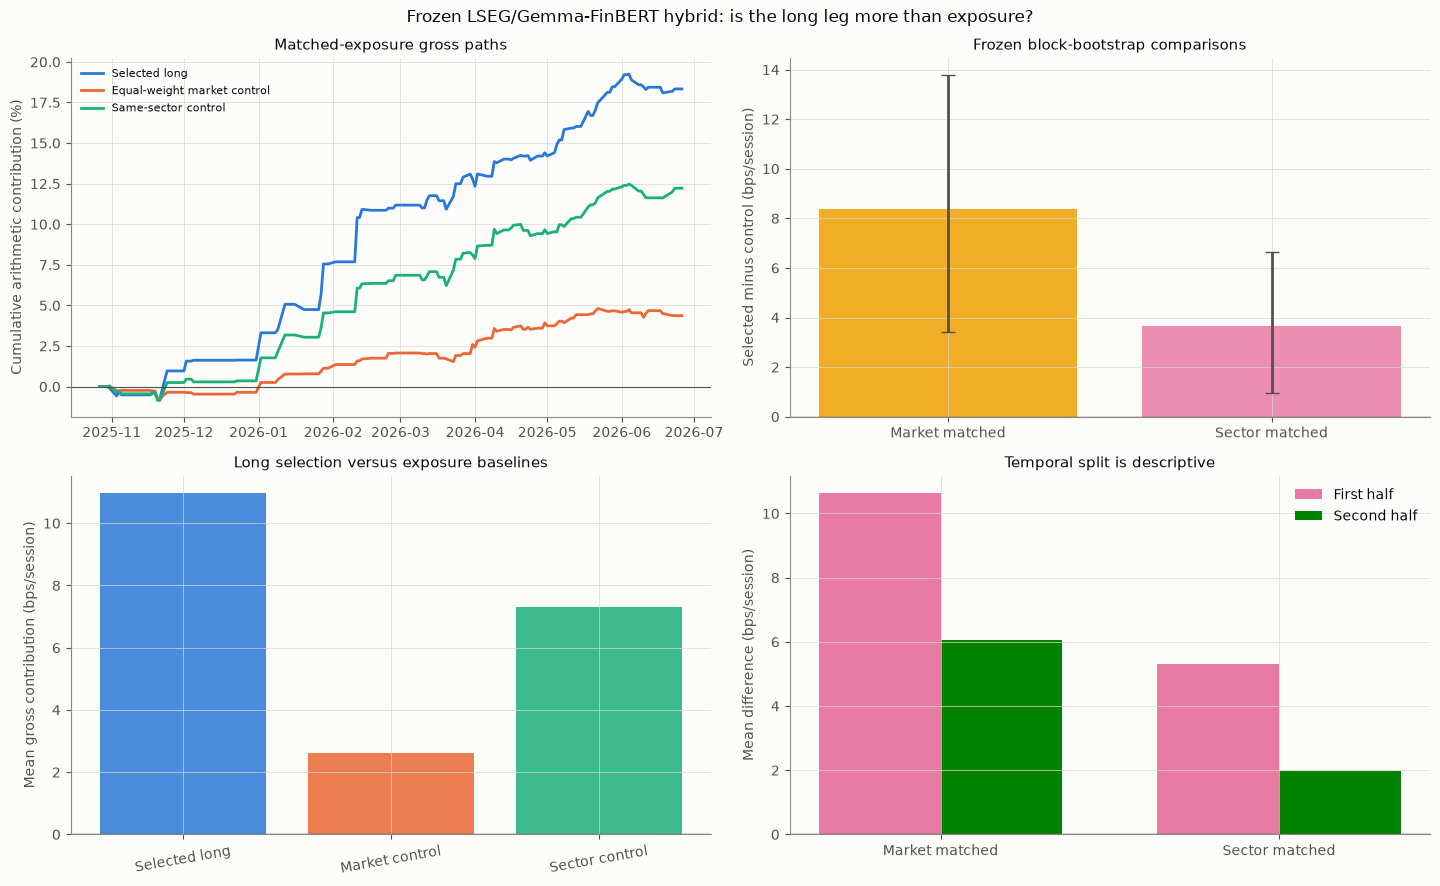

### Decision

- Selected long minus equal-weight market is **+8.36 bps/session** [+3.41, +13.78], BH q=**0.0038**.
- Selected long minus same-sector equal weight is **+3.66 bps/session** [+0.95, +6.62], BH q=**0.0121**.
- Frozen mechanism classification: **both**. This does not create a control strategy, change the prospective contract, or validate alpha.

{
  "mechanism_class": "both",
  "selected_long_beats_equal_weight_market": true,
  "selected_long_beats_same_sector_equal_weight": true,
  "market_difference_bps_session": 8.361602793465062,
  "market_difference_ci_low_bps_session": 3.407267524053403,
  "market_difference_ci_high_bps_session": 13.78035486121097,
  "market_difference_bh_q": 0.0038,
  "sector_difference_bps_session": 3.6619327346980057,
  "sector_difference_ci_low_bps_session": 0.952155942193852,
  "sector_difference_ci_high_bps_session": 6.623387917783684,
  "sector_difference_bh_q": 0.0121,
  "new_traded_strategy_constructed": false,
  "cost_or_turnover_comparison_constructed": false,
  "prospective_contract_changed": false,
  "validated_alpha": false,
  "deployment_qualified": false
}


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14.5, 9.0))
for label, column, color in (
    ('Selected long', 'selected_long_gross_contribution', CATEGORICAL[0]),
    ('Equal-weight market control', 'equal_weight_market_gross_contribution', CATEGORICAL[1]),
    ('Same-sector control', 'same_sector_equal_weight_gross_contribution', CATEGORICAL[2]),
):
    axes[0, 0].plot(daily['session_date'], 100 * daily[column].cumsum(), lw=2.0, label=label, color=color)
axes[0, 0].axhline(0, color=INK['reference'], lw=0.8)
axes[0, 0].set_ylabel('Cumulative arithmetic contribution (%)')
axes[0, 0].set_title('Matched-exposure gross paths')
axes[0, 0].legend(frameon=False, fontsize=8)

x = np.arange(len(inference_table))
means = inference_table['mean_difference_bps_session'].to_numpy(dtype=float)
lower = means - inference_table['ci_low_bps_session'].to_numpy(dtype=float)
upper = inference_table['ci_high_bps_session'].to_numpy(dtype=float) - means
axes[0, 1].bar(x, means, color=CATEGORICAL[3:5], alpha=0.85)
axes[0, 1].errorbar(x, means, yerr=np.vstack([lower, upper]), fmt='none', color=INK['reference'], capsize=5)
axes[0, 1].axhline(0, color=INK['reference'], lw=1)
axes[0, 1].set_xticks(x, ['Market matched', 'Sector matched'])
axes[0, 1].set_ylabel('Selected minus control (bps/session)')
axes[0, 1].set_title('Frozen block-bootstrap comparisons')

summary_plot = control_summary.set_index('path')
axes[1, 0].bar(
    ['Selected long', 'Market control', 'Sector control'],
    summary_plot.loc[list(summary_columns), 'mean_bps_session'],
    color=CATEGORICAL[:3], alpha=0.85,
)
axes[1, 0].axhline(0, color=INK['reference'], lw=1)
axes[1, 0].set_ylabel('Mean gross contribution (bps/session)')
axes[1, 0].set_title('Long selection versus exposure baselines')
axes[1, 0].tick_params(axis='x', labelrotation=10)

width = 0.36
axes[1, 1].bar(x - width / 2, inference_table['first_half_mean_difference_bps_session'], width, color=CATEGORICAL[4], label='First half')
axes[1, 1].bar(x + width / 2, inference_table['second_half_mean_difference_bps_session'], width, color=CATEGORICAL[5], label='Second half')
axes[1, 1].axhline(0, color=INK['reference'], lw=1)
axes[1, 1].set_xticks(x, ['Market matched', 'Sector matched'])
axes[1, 1].set_ylabel('Mean difference (bps/session)')
axes[1, 1].set_title('Temporal split is descriptive')
axes[1, 1].legend(frameon=False)
fig.suptitle('Frozen LSEG/Gemma-FinBERT hybrid: is the long leg more than exposure?')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'long_leg_exposure_control.png', dpi=180, bbox_inches='tight')
plt.show()

identity.to_csv(OUTPUT_DIR / 'identity.csv', index=False)
control_summary.to_csv(OUTPUT_DIR / 'control_summary.csv', index=False)
inference_table.to_csv(OUTPUT_DIR / 'control_inference.csv', index=False)
daily.to_parquet(OUTPUT_DIR / 'daily_control_audit.parquet', index=False)
market_row = indexed.loc['selected_long_minus_equal_weight_market']
sector_row = indexed.loc['selected_long_minus_same_sector_equal_weight']
decision = {
    'mechanism_class': mechanism_class,
    'selected_long_beats_equal_weight_market': market_pass,
    'selected_long_beats_same_sector_equal_weight': sector_pass,
    'market_difference_bps_session': float(market_row['mean_difference_bps_session']),
    'market_difference_ci_low_bps_session': float(market_row['ci_low_bps_session']),
    'market_difference_ci_high_bps_session': float(market_row['ci_high_bps_session']),
    'market_difference_bh_q': float(market_row['bh_q_value']),
    'sector_difference_bps_session': float(sector_row['mean_difference_bps_session']),
    'sector_difference_ci_low_bps_session': float(sector_row['ci_low_bps_session']),
    'sector_difference_ci_high_bps_session': float(sector_row['ci_high_bps_session']),
    'sector_difference_bh_q': float(sector_row['bh_q_value']),
    'new_traded_strategy_constructed': False,
    'cost_or_turnover_comparison_constructed': False,
    'prospective_contract_changed': False,
    'validated_alpha': False,
    'deployment_qualified': False,
}
try:
    git_commit = subprocess.run(['git', 'rev-parse', 'HEAD'], cwd=REPO_ROOT, check=True, capture_output=True, text=True).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None
manifest = {
    'status': 'RETROSPECTIVE_OPENED_WINDOW_LONG_LEG_EXPOSURE_CONTROL',
    'notebook': '60_lseg_gemma_hybrid_long_leg_exposure_control.ipynb',
    'git_commit_at_execution': git_commit,
    'frozen_spec_sha256': hashlib.sha256(SPEC_PATH.read_bytes()).hexdigest(),
    'specification': spec,
    'input_boundary': {
        'gemma_aggregate_panel': str(GEMMA_PATH.relative_to(REPO_ROOT)),
        'finbert_aggregate_panel': str(FINBERT_PATH.relative_to(REPO_ROOT)),
        'price_path': str(PRICE_PATH.relative_to(REPO_ROOT)),
        'notebook59_daily': str(NOTEBOOK59_DAILY_PATH.relative_to(REPO_ROOT)),
        'licensed_headline_text_loaded': False, 'licensed_text_emitted': False,
        'source_regimes_pooled': False, 'row_level_control_audit_persisted_local_only': True,
    },
    'identity': json.loads(identity.to_json(orient='records'))[0],
    'control_summary': json.loads(control_summary.to_json(orient='records')),
    'control_inference': json.loads(inference_table.to_json(orient='records')),
    'decision': decision,
    'claim_boundary': {
        'new_signal_constructed': False, 'new_traded_strategy_constructed': False,
        'historical_retuning_performed': False, 'cost_or_turnover_comparison_constructed': False,
        'prospective_contract_changed': False, 'alpha_promotion_permitted': False,
    },
    'limitations': [
        'The candidate, return window, and decision to inspect its long leg were selected before this post-result diagnostic.',
        'Control paths are gross arithmetic counterfactual contributions, not independently executable strategies.',
        'The broad-market comparison retains timing and total long exposure but not sector exposure.',
        'The same-sector comparison isolates within-sector name placement but does not identify causal sentiment information.',
        'Daily bars omit spreads, auction slippage, market impact, financing, borrow, and order-book depth.',
        'Split-adjusted price returns exclude dividends.',
        'Human semantic validation and genuinely new-date replay remain required.',
    ],
}
(OUTPUT_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2) + '\n')

display(Markdown(
    '### Decision\n\n'
    f"- Selected long minus equal-weight market is **{market_row['mean_difference_bps_session']:+.2f} bps/session** "
    f"[{market_row['ci_low_bps_session']:+.2f}, {market_row['ci_high_bps_session']:+.2f}], BH q=**{market_row['bh_q_value']:.4f}**.\n"
    f"- Selected long minus same-sector equal weight is **{sector_row['mean_difference_bps_session']:+.2f} bps/session** "
    f"[{sector_row['ci_low_bps_session']:+.2f}, {sector_row['ci_high_bps_session']:+.2f}], BH q=**{sector_row['bh_q_value']:.4f}**.\n"
    f"- Frozen mechanism classification: **{mechanism_class}**. This does not create a control strategy, change the prospective contract, or validate alpha."
))
print(json.dumps(decision, indent=2))

## Next steps

1. Preserve either pass or null as a mechanism result; do not use it to reselect the historical strategy.
2. Keep the exact Notebook 36 long/short candidate unchanged in the frozen prospective replay.
3. If the same-sector comparison is weak, describe the historical long result as exposure- or sector-placement-shaped rather than single-name sentiment alpha.
4. Require genuinely new dates and the existing human semantic audit before any promotion claim.